In [1]:
import torch
import os

def load_model_from_checkpoint(model, checkpoint_path, device):
    """
    Load trained model weights from checkpoint.

    Args:
        model (torch.nn.Module): initialized model architecture
        checkpoint_path (str): path to .pt or .pth checkpoint
        device (torch.device)

    Returns:
        torch.nn.Module: model with loaded weights in eval mode
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    return model

In [2]:
import torch
from src.utils.diffusion import Diffusion

@torch.no_grad()
def run_diffusion_inference(
    model,
    init_image,
    cond_mask,
    diffusion_config,
    sampling_method="ddim",
    sampling_steps=50,
    ddim_eta=0.0,
    device="cuda"
):
    """
    Run conditional DDPM/DDIM sampling.

    Args:
        model: trained diffusion model
        init_image (Tensor): (16, 256, 256) random noise
        cond_mask (Tensor): (3, 256, 256) one-hot condition mask
        diffusion_config (dict): config["diffusion"]
        sampling_method (str): "ddim" or "ddpm"
        sampling_steps (int)
        ddim_eta (float)
        device (str or torch.device)

    Returns:
        output (Tensor): generated image (16, 256, 256)
        cond_mask (Tensor): condition mask (3, 256, 256)
    """
    model.eval()

    # Ensure batch dimension
    x = init_image.unsqueeze(0).to(device)      # (1, 16, 256, 256)
    cond = cond_mask.unsqueeze(0).to(device)    # (1, 3, 256, 256)

    diffusion = Diffusion(
        timesteps=diffusion_config["timesteps"],
        beta_schedule=diffusion_config["beta_schedule"],
        device=device,
    )

    if sampling_method == "ddim":
        output = diffusion.ddim_sample(
            model=model,
            shape=x.shape,
            cond=cond,
            num_steps=sampling_steps,
            eta=ddim_eta
        )
    elif sampling_method == "ddpm":
        output = diffusion.p_sample_loop(
            model=model,
            shape=x.shape,
            cond=cond,
            num_steps=sampling_steps
        )
    else:
        raise ValueError(f"Unknown sampling method: {sampling_method}")

    return output.squeeze(0).cpu(), cond_mask.cpu()


In [55]:
import matplotlib.pyplot as plt
import numpy as np

def plot_output_and_mask(
    output,
    cond_mask,
    output_channel=0,
    figsize=(10, 4)
):
    """
    Plot generated output and condition mask.

    Args:
        output (Tensor): (16, 256, 256)
        cond_mask (Tensor): (3, 256, 256)
        output_channel (int): which output channel to visualize
        figsize (tuple)
    """
    output_np = output.numpy()
    cond_np = cond_mask.numpy()

    # Select output channel
    out_vis = output_np[output_channel]

    # Convert one-hot mask → class labels
    cond_vis = np.max(cond_np, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].imshow(out_vis, cmap="gray")
    axes[0].set_title(f"Generated Output (channel {output_channel})")
    axes[0].axis("off")

    im = axes[1].imshow(cond_vis, cmap="tab10", vmin=0, vmax=cond_np.shape[0] - 1)
    axes[1].set_title("Condition Mask")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], label="Class")

    plt.tight_layout()
    plt.show()


In [56]:
from omegaconf import OmegaConf
def load_config(config_path):
    config = OmegaConf.load(config_path)
    return OmegaConf.to_container(config, resolve=True)

In [57]:
import os
experiment_path = "/nfshome/schubbe/PycharmProjects/iScat-diffusion/experiments/iscat_ddpm_2026-01-23_21-21-38/"
config = load_config(experiment_path + "config.yaml")
checkpoint_path = experiment_path + "best_model.pt"

In [63]:
import torch

def centered_circle_tensor(shape, radius=None, device="cpu", dtype=torch.float32):
    """
    Generate a tensor with zeros everywhere except a centered circle of ones.
    The circle is duplicated across all leading dimensions (e.g. channels).

    Args:
        shape (tuple): (C, H, W) or (..., H, W)
        radius (int or float, optional)
        device (str or torch.device)
        dtype (torch.dtype)

    Returns:
        torch.Tensor: shape == input shape
    """
    *prefix, H, W = shape

    if radius is None:
        radius = min(H, W) // 4

    # Coordinate grid
    y = torch.arange(H, device=device).view(H, 1)
    x = torch.arange(W, device=device).view(1, W)

    cy = (H - 1) / 2.0
    cx = (W - 1) / 2.0

    dist = (x - cx) ** 2 + (y - cy) ** 2
    circle_2d = (dist <= radius ** 2).to(dtype)  # (H, W)

    # Expand + repeat across prefix dimensions
    if prefix:
        circle = circle_2d.unsqueeze(0)           # (1, H, W)
        repeat_shape = (*prefix, 1, 1)
        circle = circle.repeat(*prefix, 1, 1)     # (C, H, W) or (..., H, W)
    else:
        circle = circle_2d

    return circle
import torch

def multiple_circles_tensor(
    shape,
    num_particles,
    radius,
    device="cpu",
    dtype=torch.float32
):
    """
    Generate a tensor with multiple circular particles (ones) on a zero background.

    Args:
        shape (tuple): (C, H, W) or (..., H, W)
        num_particles (int): number of circles
        radius (int or float): circle radius in pixels
        device (str or torch.device)
        dtype (torch.dtype)

    Returns:
        torch.Tensor: tensor of shape `shape`
    """
    *prefix, H, W = shape

    # Coordinate grid
    y = torch.arange(H, device=device).view(H, 1)
    x = torch.arange(W, device=device).view(1, W)

    mask_2d = torch.zeros((H, W), device=device, dtype=dtype)

    for _ in range(num_particles):
        cy = torch.randint(radius, H - radius, (1,), device=device).item()
        cx = torch.randint(radius, W - radius, (1,), device=device).item()

        dist = (x - cx) ** 2 + (y - cy) ** 2
        circle = (dist <= radius ** 2).to(dtype)

        mask_2d = torch.maximum(mask_2d, circle)

    # Duplicate across prefix dimensions (channels, batch, etc.)
    if prefix:
        mask = mask_2d.unsqueeze(0).repeat(*prefix, 1, 1)
    else:
        mask = mask_2d

    return mask


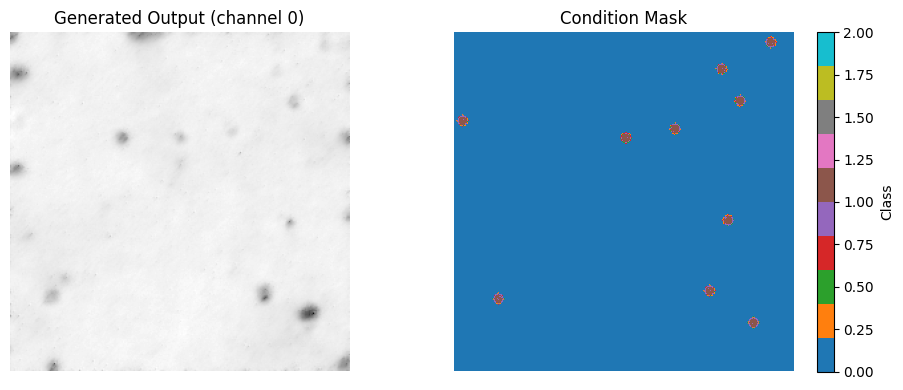

In [108]:
from src.models.model import U_Net
device = torch.device("cuda")

model = U_Net(
    img_ch=config["data"]["z_chunk_size"],
    cond_ch=config["data"]["mask_channels"],
    output_ch=config["data"]["z_chunk_size"],
).to(device)
model = load_model_from_checkpoint(model, checkpoint_path, device)

init_image = torch.randn(16, 256, 256)
cond_mask = torch.randint(0, 2, (3, 256, 256)).float()
cond_mask = centered_circle_tensor((3, 256, 256), radius=8, device="cuda", dtype=torch.float32)
cond_mask = multiple_circles_tensor((3, 256, 256), radius=4, device="cuda", dtype=torch.float32, num_particles= 10)
# cond_mask = torch.ones((3, 256, 256)).float()
output, cond = run_diffusion_inference(
    model,
    init_image,
    cond_mask,
    diffusion_config = config["diffusion"],
    sampling_method = "ddim",
    sampling_steps = 500
)

plot_output_and_mask(output, cond, output_channel=0)

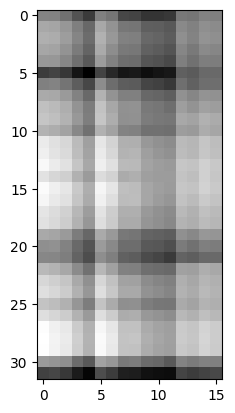

In [104]:
out = output.mean(dim=(1)).permute(1,0)
import torch.nn.functional as F
out = x_resized = F.interpolate(
    out.unsqueeze(0).unsqueeze(0),
    size=(32, 16),
    mode="bicubic",
    align_corners=False
).squeeze(0).squeeze(0)
# resize out to (16,32)

fig,ax = plt.subplots(1,1)
plt.imshow(out, cmap="gray")
plt.show()

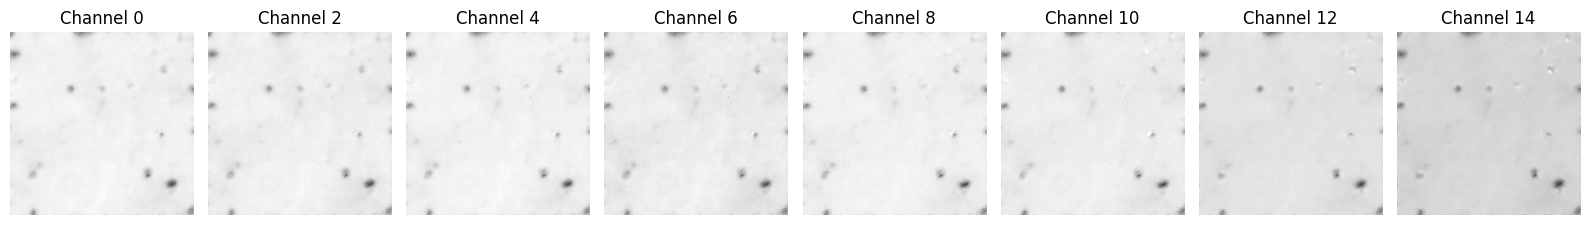

In [110]:
import matplotlib.pyplot as plt
import torch

def plot_spaced_channels(
    image,
    num_plots=8,
    cmap="gray",
    figsize=(16, 4)
):
    """
    Plot evenly spaced channels from a multi-channel grayscale image.

    Args:
        image (Tensor): shape (16, H, W)
        num_plots (int): number of channels to plot (default 8)
        cmap (str): matplotlib colormap
        figsize (tuple)
    """
    assert image.dim() == 3, "Expected shape (C, H, W)"
    C, H, W = image.shape
    assert C >= num_plots, "Not enough channels to plot"

    # Select channels: 0, 2, 4, ...
    step = C // num_plots
    channel_indices = list(range(0, C+1, step))[:num_plots]

    fig, axes = plt.subplots(1, num_plots, figsize=figsize)

    for ax, ch in zip(axes, channel_indices):
        img = image[ch].detach().cpu().numpy()
        ax.imshow(img, cmap=cmap)
        ax.set_title(f"Channel {ch}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
plot_spaced_channels(output)

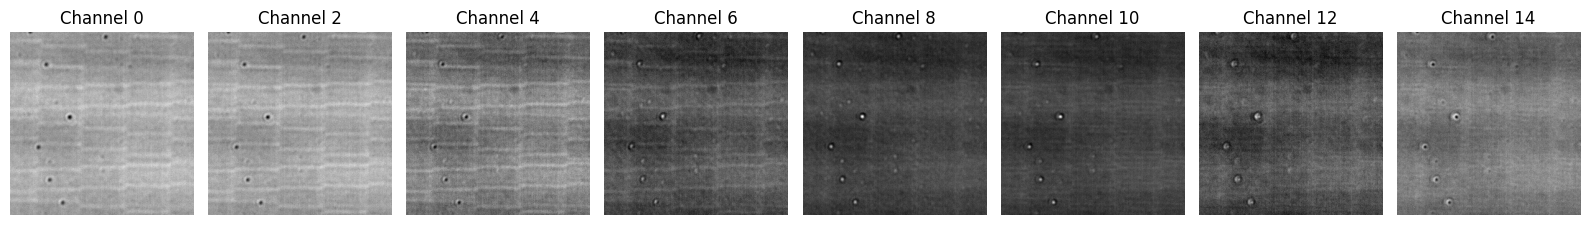

In [100]:
    from src.datasets.dataset import iScatDataset
    full_dataset = iScatDataset(
        hdf5_path="/nfshome/schubbe/brightfield.hdf5",
        classes=config["data"]["fluo_masks_indices"],
        chunk_size=config["data"]["z_chunk_size"],
        normalize=config["data"]["normalize"],
        multi_class=config["data"]["multi_class"],
        one_hot_encode=config["data"]["one_hot_encode"],
        apply_augmentation=False,
    )
    sample,mask = full_dataset[3]
    plot_spaced_channels(sample)

In [96]:
201*256*256

1048576

In [97]:
16*16*201

51456